# 02: Multivariate Anomaly Detection
## Objective
Develop a machine learning model to detect abnormal sensor patterns in real-time aquarium telemetry.

### Logic: Isolation Forest
We use the **Isolation Forest** algorithm because aquarium anomalies are rare and often consist of abnormal combinations of sensor values. This model isolates observations by randomly partitioning the feature space; anomalies are identified as points that require fewer splits (shorter path lengths) to isolate.

### Sim-to-Real Strategy
The model is validated using synthetic ground-truth labels to establish a performance baseline. This supports deployment with a pre-trained detector that can be recalibrated once real-world user feedback is collected via the dashboard.

*Note: Preprocessing is kept minimal to preserve event fidelity. Smoothing and alert persistence are handled at the application layer.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Fixed: changed 'import sns' to 'import seaborn as sns'
import joblib
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)

sns.set(style="whitegrid")

In [2]:
# Load the dataset (Path assumes execution from /notebooks folder)
df = pd.read_csv("../data/smart_aquarium_dataset_v6.1.csv")

# Convert timestamp and sort to ensure temporal continuity
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')

print(f"Dataset Loaded: {df.shape[0]} rows across {df.shape[1]} columns.")

Dataset Loaded: 8640 rows across 22 columns.


In [3]:
# Core sensors used for multivariate detection
feature_cols = ["temperature", "ph", "tds", "turbidity"]
label_col = "is_anomaly" # Ground truth for validation

# Isolate the modeling dataframe
df_model = df[feature_cols + [label_col]].copy()

In [4]:
# 1. Forward Fill short telemetry gaps (Packet Loss)
df_model[feature_cols] = df_model[feature_cols].ffill()

# 2. Filter physically impossible values (Hardware Failures)
# We keep outliers that are physically possible but environmentally abnormal
df_model = df_model[
    (df_model["ph"].between(0, 14)) &
    (df_model["temperature"].between(0, 45)) &
    (df_model["tds"] >= 0) &
    (df_model["turbidity"] >= 0)
].copy()

print("Preprocessing Complete.")
print(f"Missing Values:\n{df_model[feature_cols].isnull().sum()}")

Preprocessing Complete.
Missing Values:
temperature    0
ph             0
tds            0
turbidity      0
dtype: int64


In [5]:
print("--- Ground Truth Anomaly Distribution ---")
print(df_model[label_col].value_counts())
print("\nPercentage View:")
print(df_model[label_col].value_counts(normalize=True) * 100)

--- Ground Truth Anomaly Distribution ---
is_anomaly
0    8376
1     264
Name: count, dtype: int64

Percentage View:
is_anomaly
0    96.944444
1     3.055556
Name: proportion, dtype: float64


In [6]:
X = df_model[feature_cols].copy()
y_true = df_model[label_col].astype(int).copy()

print(f"Features ready: {feature_cols}")

Features ready: ['temperature', 'ph', 'tds', 'turbidity']


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization complete: Mean=0, Std=1")

Standardization complete: Mean=0, Std=1


In [8]:
# We use 200 estimators for better stability
iso_forest = IsolationForest(
    n_estimators=200, 
    contamination=0.06, 
    random_state=42
)

# Fit the model
iso_forest.fit(X_scaled)

print("Model training complete.")

Model training complete.


In [9]:
y_pred_raw = iso_forest.predict(X_scaled)

# Map: -1 -> 1 (Anomaly), 1 -> 0 (Normal)
y_pred = np.where(y_pred_raw == -1, 1, 0)

df_model["iforest_pred"] = y_pred
print(f"Model identified {y_pred.sum()} anomalous instances.")

Model identified 519 anomalous instances.


--- Isolation Forest Evaluation Metrics ---
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      8376
           1       0.08      0.15      0.10       264

    accuracy                           0.92      8640
   macro avg       0.52      0.55      0.53      8640
weighted avg       0.94      0.92      0.93      8640



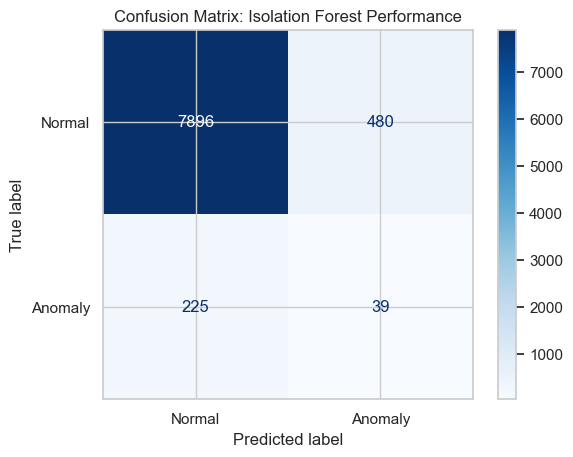

In [10]:
print("--- Isolation Forest Evaluation Metrics ---")
print(classification_report(y_true, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix: Isolation Forest Performance")
plt.show()

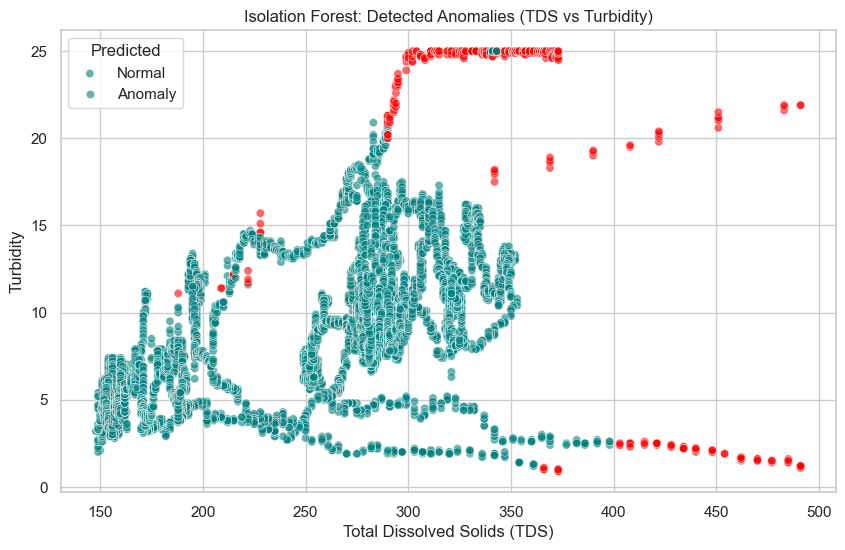

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_model, 
    x='tds', 
    y='turbidity', 
    hue='iforest_pred', 
    palette={0: 'teal', 1: 'red'}, 
    alpha=0.6
)
plt.title("Isolation Forest: Detected Anomalies (TDS vs Turbidity)")
plt.xlabel("Total Dissolved Solids (TDS)")
plt.ylabel("Turbidity")
plt.legend(title="Predicted", labels=["Normal", "Anomaly"])
plt.show()

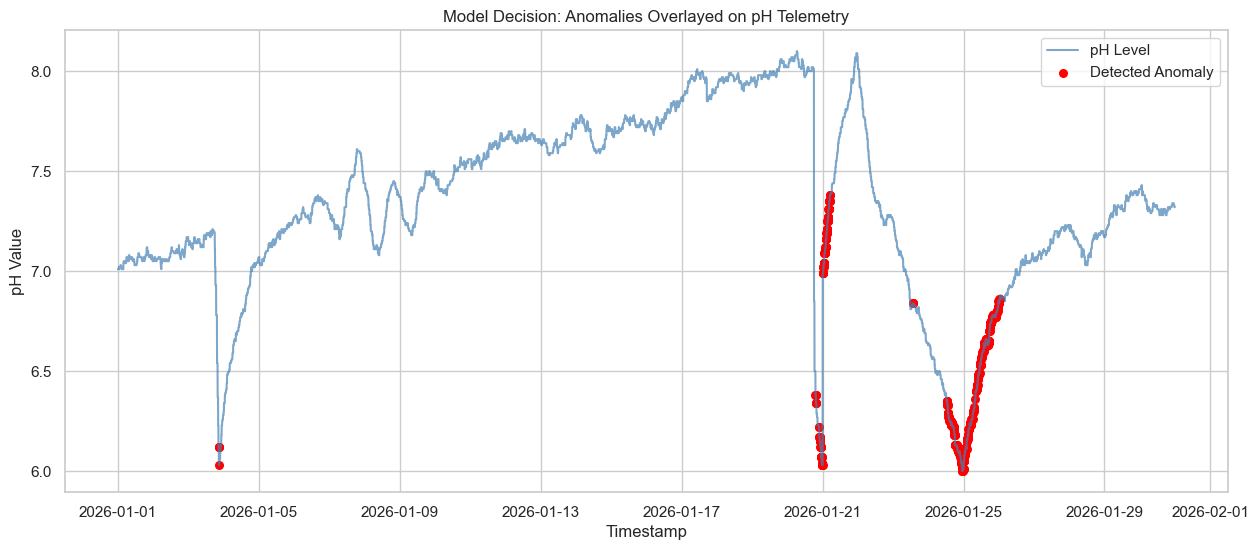

In [12]:
plt.figure(figsize=(15, 6))
plt.plot(df_model.index, df_model['ph'], label='pH Level', alpha=0.7, color='steelblue')

# Filter for the points the model flagged
anomalies = df_model[df_model['iforest_pred'] == 1]

# Overlay red dots
plt.scatter(anomalies.index, anomalies['ph'], color='red', label='Detected Anomaly', s=30)

plt.title("Model Decision: Anomalies Overlayed on pH Telemetry")
plt.xlabel("Timestamp")
plt.ylabel("pH Value")
plt.legend()
plt.show()

---
## Threshold Tuning
The Isolation Forest produces a **continuous decision score** for every observation.
Rather than relying solely on the contamination-derived cutoff (~-0.025), we evaluate
multiple thresholds and select the one that maximises the F1-score on the anomaly class.

> **Why this works:** Moving the threshold rightward labels more borderline points as
> anomalies, trading some precision for higher recall — critical when missing a real
> aquarium event is more costly than an occasional false alert.

In [13]:
# --- Step 1: Extract continuous decision scores from the trained model ---
# Lower score = more anomalous; Higher score = more normal
df_model["iforest_score"] = iso_forest.decision_function(X_scaled)

# --- Step 2: Evaluate multiple thresholds ---
# Range chosen around the default contamination cutoff (~-0.025)
thresholds = [-0.025, -0.01, 0.00, 0.01, 0.02, 0.03, 0.05, 0.08]
results = []

for t in thresholds:
    y_pred_t  = (df_model["iforest_score"] < t).astype(int)
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    recall    = recall_score(y_true, y_pred_t, zero_division=0)
    f1        = f1_score(y_true, y_pred_t, zero_division=0)
    flagged   = int(y_pred_t.sum())
    results.append({
        "threshold":     t,
        "precision":     round(precision, 3),
        "recall":        round(recall, 3),
        "f1_score":      round(f1, 3),
        "flagged_count": flagged
    })

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
print("--- Threshold Tuning Results (sorted by F1) ---")
print(results_df.to_string(index=False))

--- Threshold Tuning Results (sorted by F1) ---
 threshold  precision  recall  f1_score  flagged_count
     0.030      0.120   0.432     0.188            951
     0.050      0.103   0.485     0.170           1245
     0.020      0.108   0.333     0.163            818
     0.010      0.108   0.261     0.153            640
     0.080      0.077   0.561     0.135           1923
     0.000      0.075   0.148     0.100            519
    -0.025      0.090   0.091     0.091            266
    -0.010      0.067   0.110     0.084            430


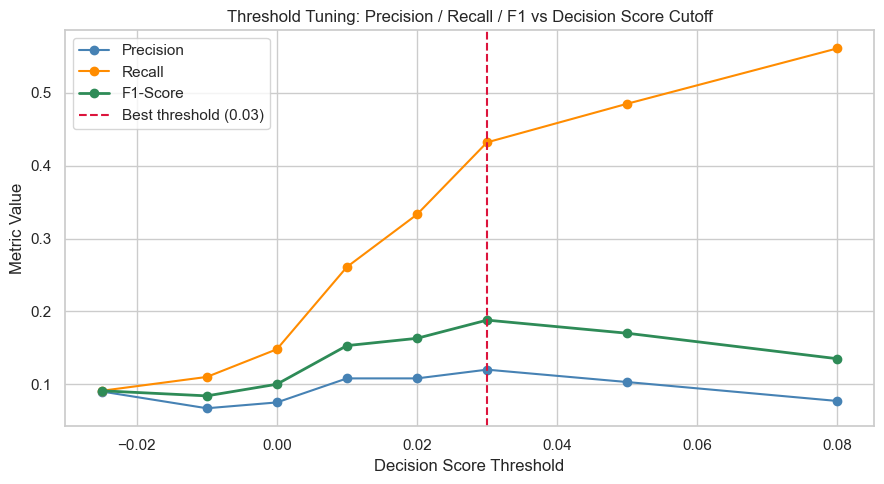

In [14]:
# --- Step 3: Visualise precision / recall / F1 tradeoff ---
plot_df = pd.DataFrame(results).sort_values("threshold")
best_t  = results_df.iloc[0]["threshold"]

plt.figure(figsize=(9, 5))
plt.plot(plot_df["threshold"], plot_df["precision"], marker="o", label="Precision", color="steelblue")
plt.plot(plot_df["threshold"], plot_df["recall"],    marker="o", label="Recall",    color="darkorange")
plt.plot(plot_df["threshold"], plot_df["f1_score"],  marker="o", label="F1-Score",  color="seagreen", linewidth=2)
plt.axvline(x=best_t, color="crimson", linestyle="--", label=f"Best threshold ({best_t})")
plt.xlabel("Decision Score Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Tuning: Precision / Recall / F1 vs Decision Score Cutoff")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# --- Step 4: Apply best threshold ---
# Default: auto-selected as the threshold with highest F1 from the table above.
# Override manually if domain knowledge suggests a different precision/recall balance.
best_threshold = float(results_df.iloc[0]["threshold"])

df_model["iforest_pred_tuned"] = (df_model["iforest_score"] < best_threshold).astype(int)

print(f"Best threshold applied  : {best_threshold}")
print(f"Flagged — tuned model   : {df_model['iforest_pred_tuned'].sum()}")
print(f"Flagged — original model: {df_model['iforest_pred'].sum()}")
print(f"Ground truth anomalies  : {y_true.sum()}")

# --- Anomaly rate summary ---
anomaly_rate = df_model["iforest_pred_tuned"].mean()
print(f"Anomaly rate detected   : {anomaly_rate*100:.2f}%")

Best threshold applied  : 0.03
Flagged — tuned model   : 951
Flagged — original model: 519
Ground truth anomalies  : 264
Anomaly rate detected   : 11.01%


--- Tuned Isolation Forest Evaluation Metrics ---
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      8376
           1       0.12      0.43      0.19       264

    accuracy                           0.89      8640
   macro avg       0.55      0.67      0.56      8640
weighted avg       0.95      0.89      0.92      8640

--- Before vs After Threshold Tuning ---
Metric         Original      Tuned      Delta
--------------------------------------------
Recall            0.148      0.432     +0.284
Precision         0.075      0.120     +0.045
F1-Score          0.100      0.188     +0.088

Matthews Correlation Coefficient (MCC): 0.1825
ROC-AUC  (score-based): 0.7033
PR-AUC   (score-based): 0.1379


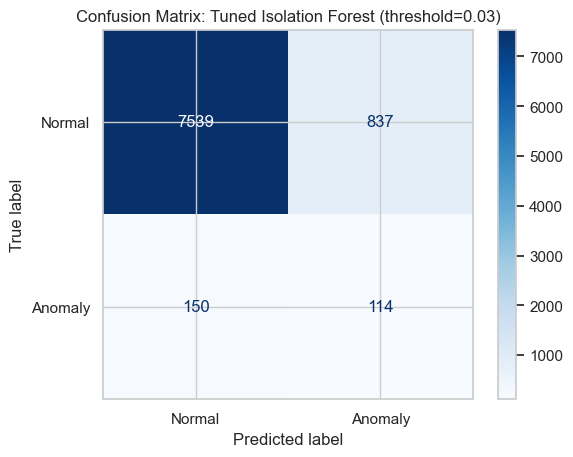

In [21]:
# --- Step 5: Re-evaluate with tuned threshold ---
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    matthews_corrcoef, roc_auc_score, average_precision_score
)

y_pred_tuned = df_model["iforest_pred_tuned"]

# --- Classification report ---
print("--- Tuned Isolation Forest Evaluation Metrics ---")
print(classification_report(y_true, y_pred_tuned))

# --- Before / After delta summary ---
orig_recall    = recall_score(y_true, df_model["iforest_pred"],    zero_division=0)
orig_precision = precision_score(y_true, df_model["iforest_pred"], zero_division=0)
orig_f1        = f1_score(y_true, df_model["iforest_pred"],        zero_division=0)

tuned_recall    = recall_score(y_true, y_pred_tuned,    zero_division=0)
tuned_precision = precision_score(y_true, y_pred_tuned, zero_division=0)
tuned_f1        = f1_score(y_true, y_pred_tuned,        zero_division=0)

print("--- Before vs After Threshold Tuning ---")
print(f"{'Metric':<12} {'Original':>10} {'Tuned':>10} {'Delta':>10}")
print("-" * 44)
print(f"{'Recall':<12} {orig_recall:>10.3f} {tuned_recall:>10.3f} {tuned_recall - orig_recall:>+10.3f}")
print(f"{'Precision':<12} {orig_precision:>10.3f} {tuned_precision:>10.3f} {tuned_precision - orig_precision:>+10.3f}")
print(f"{'F1-Score':<12} {orig_f1:>10.3f} {tuned_f1:>10.3f} {tuned_f1 - orig_f1:>+10.3f}")

# --- MCC ---
mcc = matthews_corrcoef(y_true, y_pred_tuned)
print(f"\nMatthews Correlation Coefficient (MCC): {mcc:.4f}")

# --- ROC-AUC and PR-AUC (use raw scores, not binary prediction) ---
roc_auc = roc_auc_score(y_true, -df_model["iforest_score"])
pr_auc  = average_precision_score(y_true, -df_model["iforest_score"])
print(f"ROC-AUC  (score-based): {roc_auc:.4f}")
print(f"PR-AUC   (score-based): {pr_auc:.4f}")

# --- Confusion matrix ---
cm   = confusion_matrix(y_true, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: Tuned Isolation Forest (threshold={best_threshold})")
plt.show()

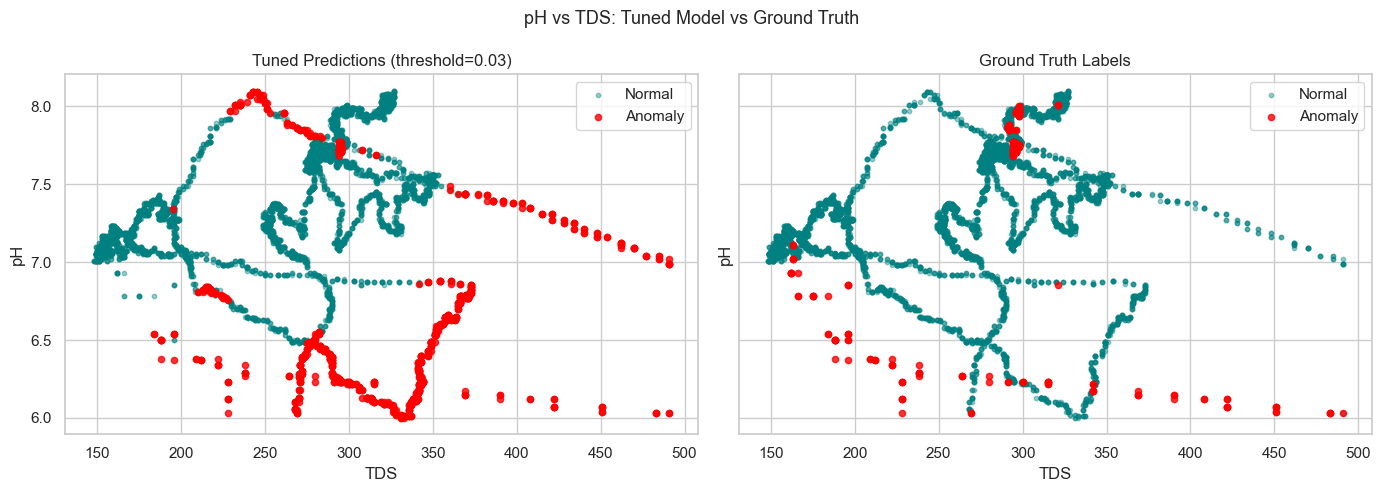

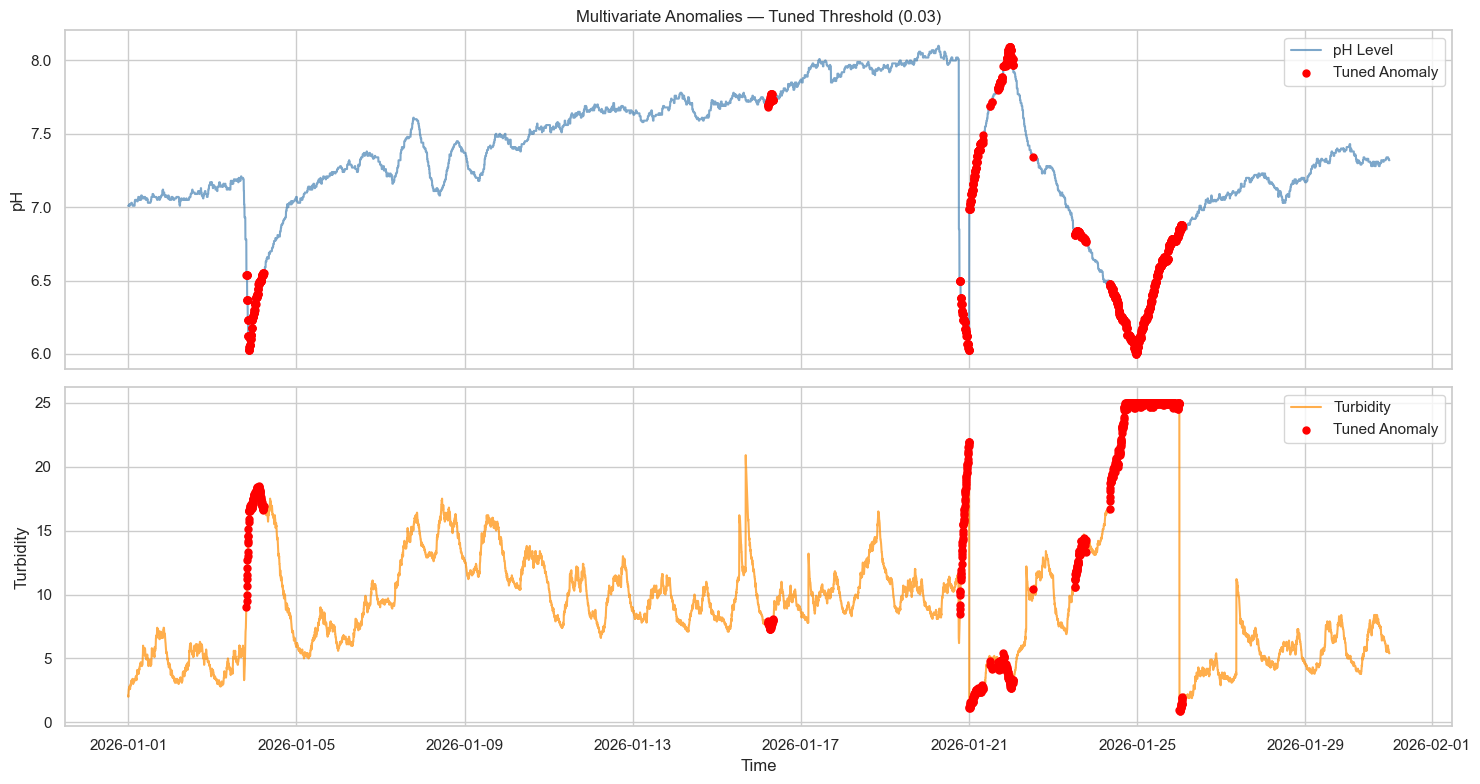

In [17]:
# --- Step 6: pH vs TDS — Tuned predictions vs Ground Truth ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, title in zip(
    axes,
    ["iforest_pred_tuned", "is_anomaly"],
    [f"Tuned Predictions (threshold={best_threshold})", "Ground Truth Labels"]
):
    normal  = df_model[df_model[col] == 0]
    anomaly = df_model[df_model[col] == 1]
    ax.scatter(normal["tds"],  normal["ph"],  c="teal", alpha=0.4, s=10, label="Normal")
    ax.scatter(anomaly["tds"], anomaly["ph"], c="red",  alpha=0.8, s=20, label="Anomaly")
    ax.set_title(title)
    ax.set_xlabel("TDS")
    ax.set_ylabel("pH")
    ax.legend()
    ax.grid(True)

plt.suptitle("pH vs TDS: Tuned Model vs Ground Truth", fontsize=13)
plt.tight_layout()
plt.show()

# --- Step 7: Dual-panel time-series — pH and Turbidity with tuned anomaly overlay ---
tuned_anom = df_model[df_model["iforest_pred_tuned"] == 1]

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# pH panel
axes[0].plot(df_model.index, df_model["ph"], color="steelblue", alpha=0.7, label="pH Level")
axes[0].scatter(tuned_anom.index, tuned_anom["ph"],
                color="red", s=25, label="Tuned Anomaly", zorder=3)
axes[0].set_ylabel("pH")
axes[0].set_title(f"Multivariate Anomalies — Tuned Threshold ({best_threshold})")
axes[0].legend()
axes[0].grid(True)

# Turbidity panel
axes[1].plot(df_model.index, df_model["turbidity"], color="darkorange", alpha=0.7, label="Turbidity")
axes[1].scatter(tuned_anom.index, tuned_anom["turbidity"],
                color="red", s=25, label="Tuned Anomaly", zorder=3)
axes[1].set_ylabel("Turbidity")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [18]:
import joblib
import os

# Create directory
model_dir = "../models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save model
joblib.dump(iso_forest, f"{model_dir}/isolation_forest_v1.joblib")

# Save scaler
joblib.dump(scaler, f"{model_dir}/scaler_v1.joblib")

print(f"Success! Model and Scaler saved to {model_dir}")

Success! Model and Scaler saved to ../models
